In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [127]:
df=pd.read_csv("Bank_Marketing_Dataset.csv")
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,2
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,2
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,2
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,1


In [128]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   V1      45211 non-null  int64
 1   V2      45211 non-null  str  
 2   V3      45211 non-null  str  
 3   V4      45211 non-null  str  
 4   V5      45211 non-null  str  
 5   V6      45211 non-null  int64
 6   V7      45211 non-null  str  
 7   V8      45211 non-null  str  
 8   V9      45211 non-null  str  
 9   V10     45211 non-null  int64
 10  V11     45211 non-null  str  
 11  V12     45211 non-null  int64
 12  V13     45211 non-null  int64
 13  V14     45211 non-null  int64
 14  V15     45211 non-null  int64
 15  V16     45211 non-null  str  
 16  Class   45211 non-null  int64
dtypes: int64(8), str(9)
memory usage: 8.0 MB


In [129]:
df.isna().sum()

V1       0
V2       0
V3       0
V4       0
V5       0
V6       0
V7       0
V8       0
V9       0
V10      0
V11      0
V12      0
V13      0
V14      0
V15      0
V16      0
Class    0
dtype: int64

In [130]:
df.duplicated().sum()

np.int64(0)

In [131]:
df.rename(columns={"V1":"Age","V2":"Type of Job","V3":"Marital Status","V4":"Education level","V5":"Has credit in default?",
        "V6":"Average yearly balance(euros)","V7":"Has a housing loan","V8":"Has a personal loan","V9":"Contact communication type",
        "V10":"Last contact day of the month","V11":"Last contact month","V12":"Last contact duration in sec","V13":"No of contacts performed during campaign for this client",
        "v14":"No of days since the client was last contacted from a previous campaign(-1 means not previously)","V15":"Number of contacts performed before this campaign for this client",
        "V16":"Outcome of the previous marketing campaign","Class":"Has client subscribed to a term deposit(1=no, 2=yes)"}, inplace=True)

In [132]:
df.head()

,Age,Type of Job,Marital Status,Education level,Has credit in default?,Average yearly balance(euros),Has a housing loan,Has a personal loan,Contact communication type,Last contact day of the month,Last contact month,Last contact duration in sec,No of contacts performed during campaign for this client,V14,Number of contacts performed before this campaign for this client,Outcome of the previous marketing campaign,"Has client subscribed to a term deposit(1=no, 2=yes)"
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


In [133]:
df["Type of Job"].value_counts()

Type of Job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [134]:
df["Education level"].value_counts()

Education level
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [135]:
df["Contact communication type"].value_counts()

Contact communication type
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [136]:
df["Last contact month"].value_counts()

Last contact month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

In [137]:
df["Outcome of the previous marketing campaign"].value_counts()

Outcome of the previous marketing campaign
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [138]:
df["Has client subscribed to a term deposit(1=no, 2=yes)"]=df["Has client subscribed to a term deposit(1=no, 2=yes)"].replace({1:"no",2:"yes"})

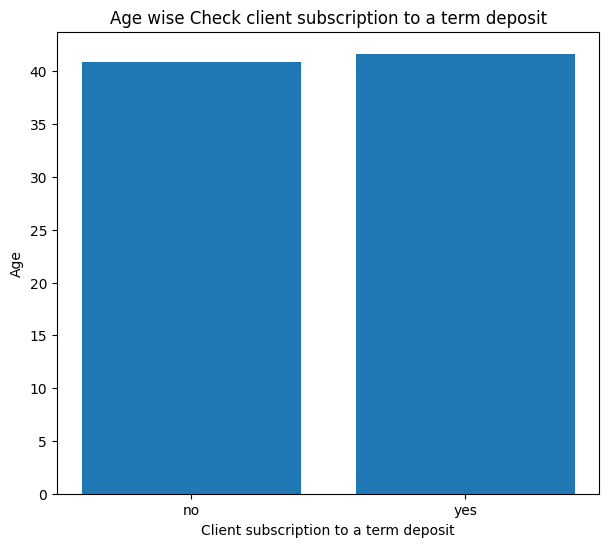

In [139]:
Avg_age=df.groupby("Has client subscribed to a term deposit(1=no, 2=yes)")["Age"].mean()

fig=plt.figure(figsize=(7,6))
fig=plt.bar(Avg_age.index, Avg_age.values)
plt.title("Age wise Check client subscription to a term deposit")
plt.xlabel("Client subscription to a term deposit")
plt.ylabel("Age")
plt.show()

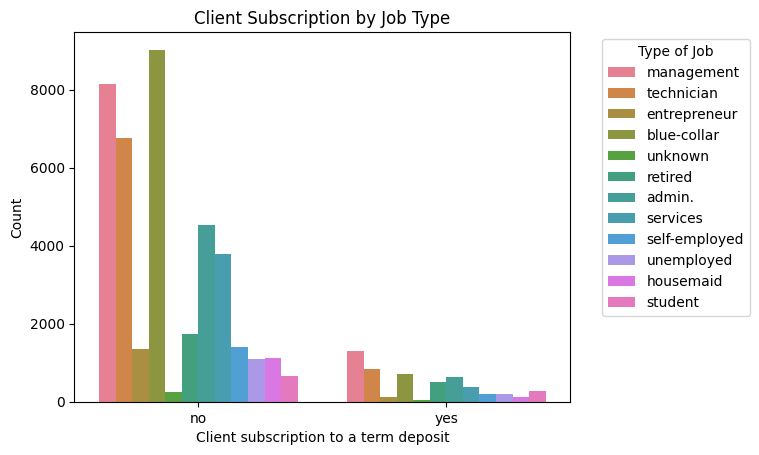

In [140]:
fig=plt.Figure(figsize=(6,7))
fig=sns.countplot(data=df,x="Has client subscribed to a term deposit(1=no, 2=yes)",hue="Type of Job")
plt.title("Client Subscription by Job Type")
plt.xlabel("Client subscription to a term deposit")
plt.ylabel("Count")
plt.legend(title="Type of Job", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

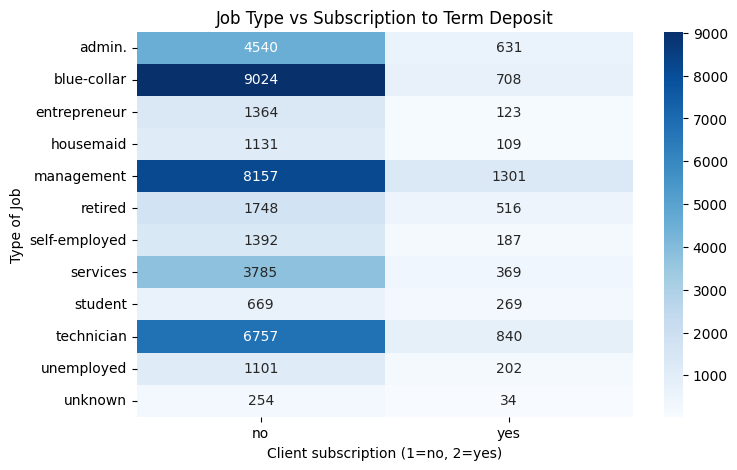

In [141]:
# sns.heatmap(df.corr(numeric_only=True))
corr = pd.crosstab(df["Type of Job"], df["Has client subscribed to a term deposit(1=no, 2=yes)"])

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, fmt="d", cmap="Blues")

plt.title("Job Type vs Subscription to Term Deposit")
plt.xlabel("Client subscription (1=no, 2=yes)")
plt.ylabel("Type of Job")
plt.show()
